In [5]:
import os

from dotenv import load_dotenv

from notion_notebook import NotebookExporter

load_dotenv()

exporter = NotebookExporter(
    notion_token=str(os.getenv("NOTION_TOKEN")),
    notion_page_id="https://www.notion.so/Simple-Example-With-plotting-33994372421b8070bc22e93c8bdf055b?source=copy_link",
)
exporter.start()

## Notion sync and this page

- **Free-form content at the top**: Add meeting notes, links, or any blocks _above_ the managed export region. Each sync replaces only the **Notebook export (...ipynb)** section and the **Notebook Metadata** callout directly above that heading. Blocks above that bundle are not modified.
- **Figures database**: The `Figures` child database remains below the export body; figure rows are synced there (images plus metadata columns).
- **Choosing the target page**: Pass `notion_page_id=` with a page URL or id, or use `notion_page_root=` with `notion_page_path=` (titles of nested child pages under the root, e.g. `"Area/Project/Task page"` or `("Area", "Project", "Task page")`).
- **Avoid calling `start()` twice** on the same notebook without `stop()`; a second watcher on the same path is skipped to satisfy macOS watchdog limits.


x


## Notion sync and this page

- **Free-form content at the top**: Add meeting notes, links, or any blocks _above_ the managed export region. Each sync replaces only the **Notebook export (...ipynb)** section and the **Notebook Metadata** callout directly above that heading. Blocks above that bundle are not modified.
- **Figures database**: The `Figures` child database remains below the export body; figure rows are synced there (images plus metadata columns).
- **Choosing the target page**: Pass `notion_page_id=` with a page URL or id, or use `notion_page_root=` with `notion_page_path=` (titles of nested child pages under the root, e.g. `"Area/Project/Task page"` or `("Area", "Project", "Task page")`).
- **Avoid calling `start()` twice** on the same notebook without `stop()`; a second watcher on the same path is skipped to satisfy macOS watchdog limits.


# Demo: plotting scaffold

Reproducible fake data and a small gallery of common Matplotlib patterns you can copy or trim. Figures use a fixed RNG seed and the default inline backend in Jupyter.


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7, 4)})

t = np.linspace(0, 4 * np.pi, 200)
signal = np.sin(t) + 0.12 * rng.standard_normal(t.shape)
categories = ["North", "South", "East", "West"]
bar_heights = rng.integers(12, 95, size=len(categories))
df = pd.DataFrame(
    {
        "x": rng.normal(0, 1, 120),
        "y": 0.55 * rng.normal(0, 1, 120) + 0.35 * rng.normal(0, 1, 120),
        "arm": rng.choice(["ctrl", "trt_a", "trt_b"], 120, p=[0.34, 0.33, 0.33]),
    }
)
heatmap_z = np.corrcoef(rng.standard_normal((6, 40)))
group_series = [df.loc[df["arm"] == g, "x"].values for g in ["ctrl", "trt_a", "trt_b"]]

## Figure 1: line, scatter, histogram, bars, box, heatmap

Two-by-three grid of high-frequency chart types.


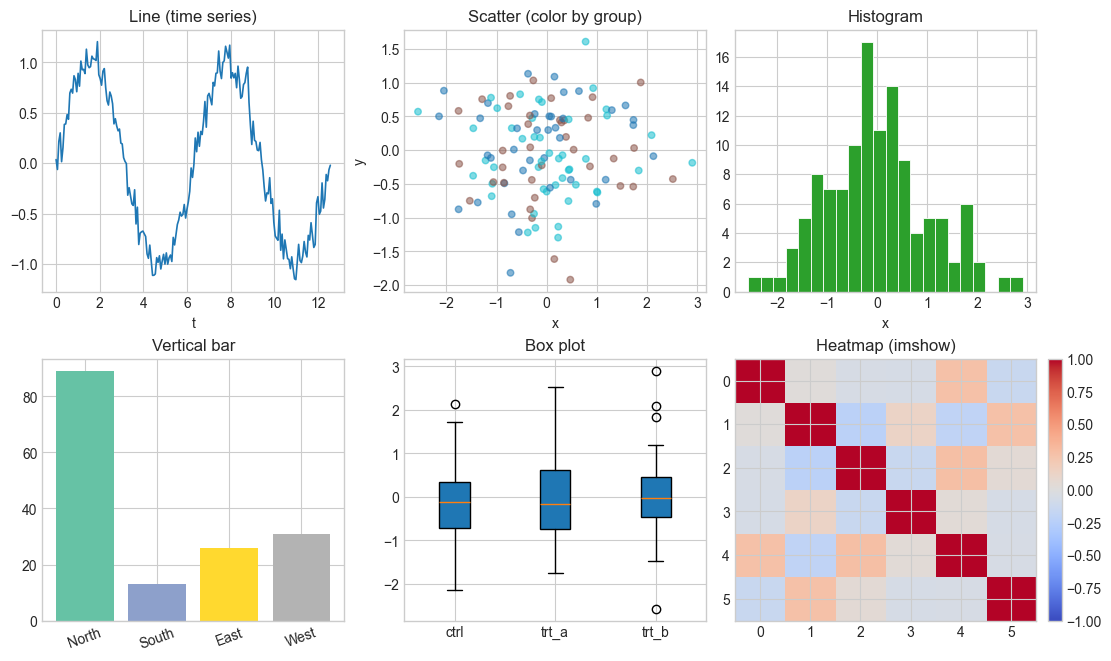

In [9]:
fig1, axs = plt.subplots(2, 3, figsize=(11, 6.5), constrained_layout=True)
axs[0, 0].plot(t, signal, color="C0", linewidth=1.2)
axs[0, 0].set_title("Line (time series)")
axs[0, 0].set_xlabel("t")
axs[0, 1].scatter(df["x"], df["y"], c=df["arm"].astype("category").cat.codes, alpha=0.55, s=22, cmap="tab10")
axs[0, 1].set_title("Scatter (color by group)")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")
axs[0, 2].hist(df["x"], bins=22, color="C2", edgecolor="white", linewidth=0.6)
axs[0, 2].set_title("Histogram")
axs[0, 2].set_xlabel("x")
_set2 = mpl.colormaps["Set2"]
axs[1, 0].bar(categories, bar_heights, color=_set2(np.linspace(0, 1, len(categories))))
axs[1, 0].set_title("Vertical bar")
axs[1, 0].tick_params(axis="x", rotation=20)
axs[1, 1].boxplot(group_series, tick_labels=["ctrl", "trt_a", "trt_b"], patch_artist=True)
axs[1, 1].set_title("Box plot")
im = axs[1, 2].imshow(heatmap_z, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
axs[1, 2].set_title("Heatmap (imshow)")
fig1.colorbar(im, ax=axs[1, 2], fraction=0.046, pad=0.04)
plt.show()

## Figure 2: pie, error bars, fill, violin, hexbin, stacked area

Second grid for other common patterns (counts, uncertainty bands, 2D density, composition).


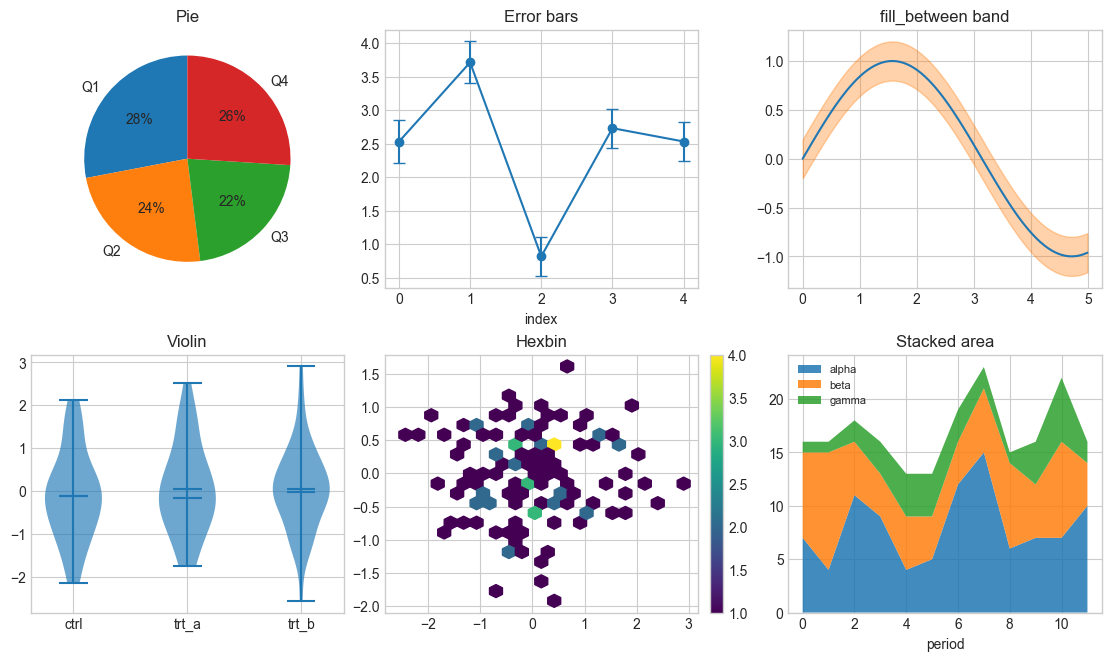

In [8]:
pie_vals = np.array([28, 24, 22, 26])
pie_labs = ["Q1", "Q2", "Q3", "Q4"]
x_err = np.arange(5)
y_err = 2.0 + 0.35 * x_err + rng.standard_normal(5)
y_err_se = 0.25 + 0.08 * rng.random(5)
fig2, axs2 = plt.subplots(2, 3, figsize=(11, 6.5), constrained_layout=True)
axs2[0, 0].pie(pie_vals, labels=pie_labs, autopct="%1.0f%%", startangle=90)
axs2[0, 0].set_title("Pie")
axs2[0, 1].errorbar(x_err, y_err, yerr=y_err_se, fmt="o-", capsize=4, color="C0")
axs2[0, 1].set_title("Error bars")
axs2[0, 1].set_xlabel("index")
axs2[0, 2].fill_between(t[:80], np.sin(t[:80]) - 0.2, np.sin(t[:80]) + 0.2, alpha=0.35, color="C1")
axs2[0, 2].plot(t[:80], np.sin(t[:80]), color="C0")
axs2[0, 2].set_title("fill_between band")
parts = axs2[1, 0].violinplot(group_series, positions=[1, 2, 3], showmeans=True, showmedians=True)
for b in parts["bodies"]:
    b.set_alpha(0.65)
axs2[1, 0].set_xticks([1, 2, 3], ["ctrl", "trt_a", "trt_b"])
axs2[1, 0].set_title("Violin")
hb = axs2[1, 1].hexbin(df["x"], df["y"], gridsize=22, cmap="viridis", mincnt=1)
axs2[1, 1].set_title("Hexbin")
fig2.colorbar(hb, ax=axs2[1, 1], fraction=0.046, pad=0.04)
days = np.arange(12)
s1 = rng.poisson(8, 12)
s2 = rng.poisson(5, 12)
s3 = rng.poisson(3, 12)
axs2[1, 2].stackplot(days, s1, s2, s3, labels=["alpha", "beta", "gamma"], alpha=0.85)
axs2[1, 2].legend(loc="upper left", fontsize=8)
axs2[1, 2].set_title("Stacked area")
axs2[1, 2].set_xlabel("period")
plt.show()